In [2]:
from GradientGang.Pipeline.DataLoader.DataLoader import DataModule

params = {
    'data_dir': "../dataset/PirateProcessed/",
    'train_file_name': "pirate_pain_train.csv",
    'train_file_name_labels': "pirate_pain_train_labels.csv",
    'test_file_name': "pirate_pain_test.csv",
    'batch_size': 32,
    'num_workers': 0,
    'val_split': 0.1,
    'shuffle': True,
}

dataLoader = DataModule(params=params)
dataLoader.setup(stage='fit')

trainLoader = dataLoader.train_dataloader()
valLoader = dataLoader.val_dataloader()

dataLoader.setup(stage='test')
testLoader = dataLoader.test_dataloader()

In [3]:
for batch in trainLoader:
    (time_series, global_features), labels = batch
    print("Train Batch - Time Series Shape:", time_series.shape)
    print("Train Batch - Global Features Shape:", global_features.shape)
    print("Train Batch - Labels Shape:", labels.shape)
    break

Train Batch - Time Series Shape: torch.Size([32, 34, 160])
Train Batch - Global Features Shape: torch.Size([32, 1])
Train Batch - Labels Shape: torch.Size([32])


In [4]:
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder
from torchsummary import summary

In [5]:
architectureParams = {
    "LearningRate": 0.001,
    "Patience": 5,
    "EncoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "Conv1d",
                "params": {
                    "in_channels": 34,
                    "out_channels": 16,
                    "kernel_size": 10,
                    "stride": 1,
                    "padding": 1,
                    "bias": True,
                    "device": None,
                    "dtype": None
                },
            },
            {
                "name": "Conv1d",
                "params": {
                    "in_channels": 16,
                    "out_channels": 32,
                    "kernel_size": 3,
                    "stride": 1,
                    "padding": 1,
                    "bias": True,
                    "device": None,
                    "dtype": None
                },
            },
            {
                "name": "Conv1d",
                "params": {
                    "in_channels": 32,
                    "out_channels": 64,
                    "kernel_size": 3,
                    "stride": 1,
                    "padding": 1,
                    "bias": True,
                    "device": None,
                    "dtype": None
                },
            },
            {
                "name": "Flatten",
                "params": {}
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 9792, 
                    "out_features": 128,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            }
        ]
    },
    "DecoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 128,
                    "out_features": 9792,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
            {
                "name": "Unflatten",
                "params": {
                    "dim": 1,
                    "unflattened_size": [64, 153]
                }
            },
            {
                "name": "ConvTranspose1d",
                "params": {
                    "in_channels": 64,
                    "out_channels": 32,
                    "kernel_size": 3,
                    "stride": 1,
                    "padding": 1,
                    "output_padding": 0,
                    "groups": 1,
                    "dilation": 1,
                    "padding_mode": "zeros",
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
            {
                "name": "ConvTranspose1d",
                "params": {
                    "in_channels": 32,
                    "out_channels": 16,
                    "kernel_size": 3,
                    "stride": 1,
                    "padding": 1,
                    "output_padding": 0,
                    "groups": 1,
                    "dilation": 1,
                    "padding_mode": "zeros",
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
            {
                "name": "ConvTranspose1d",
                "params": {
                    "in_channels": 16,
                    "out_channels": 34,
                    "kernel_size": 10,
                    "stride": 1,
                    "padding": 1,
                    "output_padding": 0,
                    "groups": 1,
                    "dilation": 1,
                    "padding_mode": "zeros",
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            }
        ]
    },
    "FeedForwardParams": {
        "activation_function": "ReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 129,
                    "out_features": 64,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 64,
                    "out_features": 10,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            }
        ]
    },
    "GlobalFFEncoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
        ]
    },
    "GlobalFFDecoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
        ]
    },
    "OutputDim": 3
}

autoencoder = LightningAutoencoder(architectureParams)

In [6]:
summary(autoencoder.encoder)

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv1d: 2-1                       5,456
|    └─GELU: 2-2                         --
|    └─Conv1d: 2-3                       1,568
|    └─GELU: 2-4                         --
|    └─Conv1d: 2-5                       6,208
|    └─GELU: 2-6                         --
|    └─Flatten: 2-7                      --
|    └─GELU: 2-8                         --
|    └─Linear: 2-9                       1,253,504
|    └─GELU: 2-10                        --
Total params: 1,266,736
Trainable params: 1,266,736
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv1d: 2-1                       5,456
|    └─GELU: 2-2                         --
|    └─Conv1d: 2-3                       1,568
|    └─GELU: 2-4                         --
|    └─Conv1d: 2-5                       6,208
|    └─GELU: 2-6                         --
|    └─Flatten: 2-7                      --
|    └─GELU: 2-8                         --
|    └─Linear: 2-9                       1,253,504
|    └─GELU: 2-10                        --
Total params: 1,266,736
Trainable params: 1,266,736
Non-trainable params: 0

In [7]:
summary(autoencoder.decoder)

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Linear: 2-1                       1,263,168
|    └─GELU: 2-2                         --
|    └─Unflatten: 2-3                    --
|    └─GELU: 2-4                         --
|    └─ConvTranspose1d: 2-5              6,176
|    └─GELU: 2-6                         --
|    └─ConvTranspose1d: 2-7              1,552
|    └─GELU: 2-8                         --
|    └─ConvTranspose1d: 2-9              5,474
Total params: 1,276,370
Trainable params: 1,276,370
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Linear: 2-1                       1,263,168
|    └─GELU: 2-2                         --
|    └─Unflatten: 2-3                    --
|    └─GELU: 2-4                         --
|    └─ConvTranspose1d: 2-5              6,176
|    └─GELU: 2-6                         --
|    └─ConvTranspose1d: 2-7              1,552
|    └─GELU: 2-8                         --
|    └─ConvTranspose1d: 2-9              5,474
Total params: 1,276,370
Trainable params: 1,276,370
Non-trainable params: 0

In [8]:
from pytorch_lightning import Trainer

trainer = Trainer(max_epochs=20, enable_progress_bar=True)
trainer.fit(autoencoder, trainLoader, valLoader)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | encoder          | Encoder           | 1.3 M  | eval 
1 | decoder          | Decoder           | 1.3 M  | eval 
2 | globalff_encoder | FeedForward       | 2      | train
3 | globalff_decoder | FeedForward       | 2      | train
4 | feedforward      | FeedForward       | 9.0 K  | train
5 | val_f1           | MulticlassF1Score | 0      | train
---------------------------------------------------------------
2.6 M     Trainable params
0         Non-trainable params
2.6 M     Total params
10.208    Total estimated model params size (MB)
14        Modules in train mode
23        Modules in ev

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Polimi\Master\3sem\ANN_challenges\GradientGang\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Polimi\Master\3sem\ANN_challenges\GradientGang\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Polimi\Master\3sem\ANN_challenges\GradientGang\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:527: Found 23 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [10]:
#Compute F1 score on val set
from torchmetrics import F1Score
import torch

all_preds = []
all_labels = []
for batch in valLoader:
    x, labels = batch
    with torch.no_grad():
        preds = autoencoder(x)[0]
    
    all_preds.extend(preds.argmax(dim=1).cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

print(all_labels)
print(all_preds)

f1 = F1Score(task="multiclass", num_classes=3, average="macro")
f1 = f1(torch.tensor(all_preds), torch.tensor(all_labels))
print("Validation F1 Score:", f1)

[np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(1), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0)]
[np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0

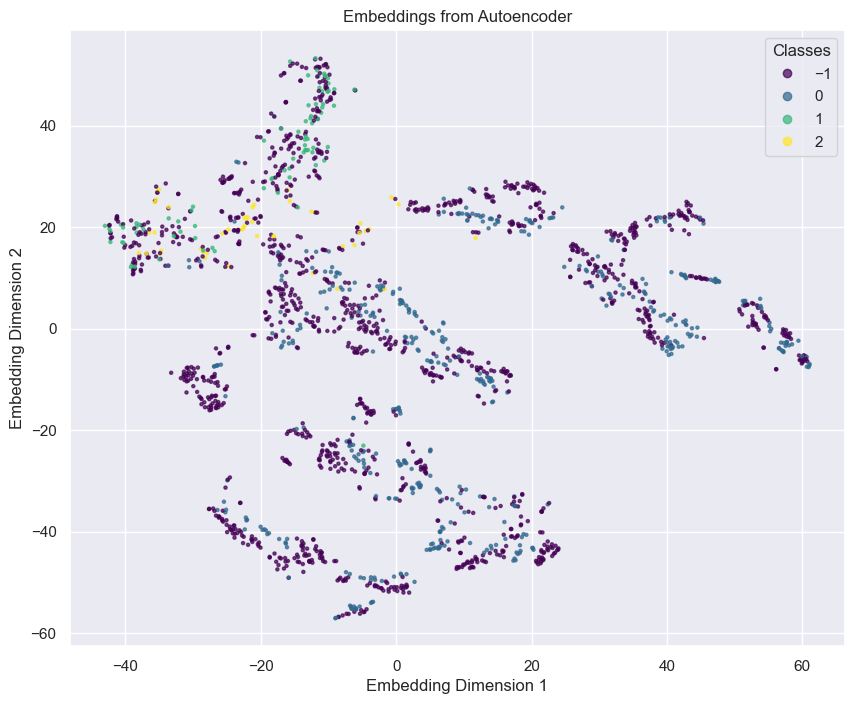

In [14]:
# plot embeddings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torch
sns.set_theme()

embeddings = []
labels_list = []
for batch in trainLoader:
    (time_series, global_features), labels = batch
    with torch.no_grad():
        # Encoder expects the time-series tensor (batch, channels, seq_len)
        embedding = autoencoder.encoder(time_series)
    embeddings.append(embedding.cpu())
    labels_list.append(labels)

embeddings = torch.cat(embeddings, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_list, alpha=0.7, cmap='viridis', s=5)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Embeddings from Autoencoder')
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
plt.show()